# Control voltages 
Example using and testing the control voltages module. Main purpose is to compute the desired active coil voltages for a given set of target shifts, using virtual circuits.
- setting up an equi, computing and saving some VCs.
- computing voltages with default VC params
- computing voltages with VC's loaded from file 



In [1]:
### IMPORTS ###
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time 
import os 
import pickle 


%load_ext autoreload
%autoreload 2


## set machine config paths 

os.environ["ACTIVE_COILS_PATH"] = (
    f"/Users/alasdair.ross/Documents/HARTREE/freegsnke_starters/machine_data/MAST-U_active_coils.pickle"
)
os.environ["PASSIVE_COILS_PATH"] = (
    f"/Users/alasdair.ross/Documents/HARTREE/freegsnke_starters/machine_data/MAST-U_passive_coils.pickle"
)
os.environ["WALL_PATH"] = (
    f"/Users/alasdair.ross/Documents/HARTREE/freegsnke_starters/machine_data/MAST-U_wall.pickle"
)
os.environ["LIMITER_PATH"] = (
    f"/Users/alasdair.ross/Documents/HARTREE/freegsnke_starters/machine_data/MAST-U_limiter.pickle"
)

# freesgnke imports (after env variables set)
from freegsnke import machine_config
from freegsnke import virtual_circuits as vc
from freegsnke.nonlinear_solve import nl_solver

from freegs4e.plotting import plotEquilibrium as plot_eqi



/Users/alasdair.ross/Documents/HARTREE/freegs4e/freegs4e/critical.py:49: UserWarning: Numba not found, using slower version
  warnings.warn("Numba not found, using slower version")


## creating and saving some VC's 
First we need some example equilibria and vc's for these. We need an equilibrium object and a profiles object, and also a non linear solver object.





In [2]:
from freegs4e.gradshafranov import mu0  # permeability
from freegsnke import GSstaticsolver, build_machine, equilibrium_update, jtor_update
from freegsnke import virtual_circuits as vc
from freegsnke.jtor_update import Lao85


def create_equilibrium(plasma_psi=None) -> tuple:

    tokamak = build_machine.tokamak()

    eq = equilibrium_update.Equilibrium(
        tokamak=tokamak,  # provide tokamak object
        Rmin=0.1,
        Rmax=2.0,  # radial range
        Zmin=-2.2,
        Zmax=2.2,  # vertical range
        nx=129,  # number of grid points in the radial direction (needs to be of the form (2**n + 1) with n being an integer)
        ny=129,  # number of grid points in the vertical direction (needs to be of the form (2**n + 1) with n being an integer)
        # psi=plasma_psi
    )

    alpha = np.array([1, 0, -1])
    beta = (1 - 0.3) / 0.3 * alpha * mu0

    profiles = Lao85(
        eq=eq,
        limiter=tokamak.limiter,
        Ip=6e5,
        fvac=0.5,
        alpha=alpha,
        beta=beta,
        alpha_logic=False,
        beta_logic=False,
        Ip_logic=True,
    )

    # Define solver
    GSStaticSolver = GSstaticsolver.NKGSsolver(eq)

    return eq, profiles, GSStaticSolver


# base equi and profiles and solver - contains machine informatoin and greens functions
eq, profiles, solver = create_equilibrium()
GSStaticSolver = GSstaticsolver.NKGSsolver(eq)

No probe configuration is provided


Now load some example equilibrium data, and solve for some equilibria. Save in a list of eqi's.

In [3]:
data = pd.read_csv(
    "/Users/alasdair.ross/Documents/HARTREE/Papers/emu_ieee/Nico_comparison/filtered_fgs_3sig_fgs.csv"
)
data = data.iloc[:10]

full_coil_list = list(eq.tokamak.getCurrents().keys())[:12]
data_currents = (
    data.loc[
        :,
        [
            "input/Solenoid",
            "input/px",
            "input/d1",
            "input/d2",
            "input/d3",
            "input/dp",
            "input/d5",
            "input/d6",
            "input/d7",
            "input/p4",
            "input/p5",
            "input/p6",
        ],
    ]
).to_numpy()
data_profiles = (
    data.loc[
        :,
        [
            "input/Ip",
            "input/alpha0",
            "input/alpha1",
            "input/beta0",
            "input/beta1",
            "input/fvac",
        ],
    ]
).to_numpy()
data_targets = (
    data.loc[
        :,
        [
            "target/Rin",
            "target/Rout",
            "target/Rxd",
            "target/Zxd",
            "target/strike_mid_X",
        ],
    ]
).to_numpy()


def load_from_table(index, eq=eq, psi0=None):

    if psi0 is not None:
        eq.plasma_psi = 1.0 * psi0

    for i, coil in enumerate(full_coil_list):
        eq.tokamak[coil].current = data_currents[index, i]

    profiles = Lao85(
        eq=eq,
        limiter=eq.tokamak.limiter,
        Ip=data_profiles[index, 0],
        fvac=data_profiles[index, -1],
        alpha=data_profiles[index, 1:3],
        beta=data_profiles[index, 3:5],
        alpha_logic=True,
        beta_logic=True,
        Ip_logic=True,
    )

    # call the solver
    GSStaticSolver.forward_solve(
        eq=eq,
        profiles=profiles,
        target_relative_tolerance=1e-9,
        verbose=False,  # print output
    )

    return eq, profiles

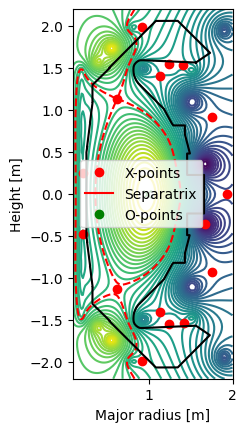

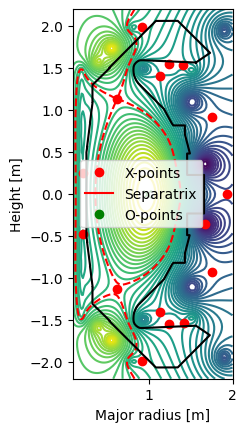

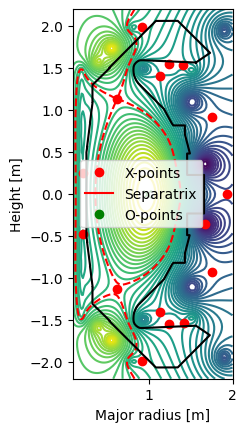

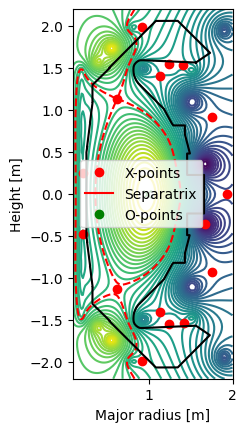

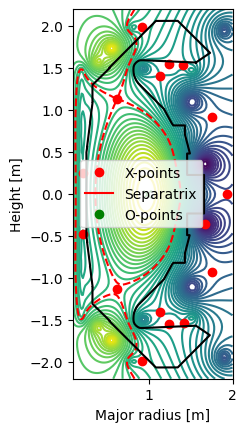

In [4]:
eqi_list = []
profiles_list = []
for i in range(10):
    eq, profiles = load_from_table(i)
    eqi_list.append(eq)
    profiles_list.append(profiles)

for j in range(5):
    plot_eqi(eqi_list[j], show=True)

with this set of equilibria we can compute the VC's and save their info in a pickle file. Note that here i've given a list of currents that is not the full set of active coils in mast u and also not the standard ordering. This is to demonstrate robustness of the voltage control class


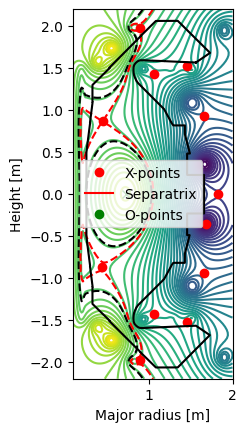

Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
More than four strikepoints located, use of 'target_option' input for Rs_lower_outer is strongly advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
More than four strikepoints located, use of 'target_option' input for Rs_lower_outer is strongly advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
More than four strikepoints located, use of 'target_option' input for Rs_lower_outer is strongly advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
More than four strikepoints located, use of 'target_option' input for Rs_lower_outer is strongly advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' inp

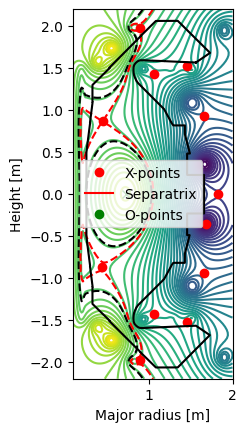

Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_optio

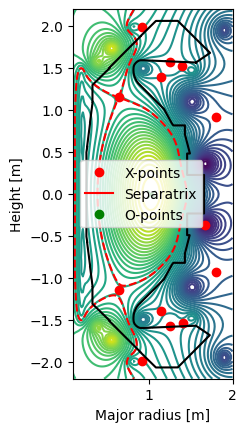

Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
Use of the 'target_optio

In [12]:
def save_vc_sequence(
    equi_list, profiles_list, coils, targets, solver, save_path="./test_saves"
):
    """open shot pickle, solve equis, compute VC, save as hdf5 and pickle"""
    VCH = vc.VirtualCircuitHandling()
    VCH.define_solver(solver, target_relative_tolerance=1e-7)

    # dict to save data to
    big_dict = {}

    timestamp_list = []
    # for i in range(len(equi_list)):
    for i in range(3):
        try:
            eq = equi_list[i]
            profiles = profiles_list[i]
            plot_eqi(eq, show=True)

            time = 0.1 * i  # dummy time variable
            input_currents = np.random.rand(len(equi_list[i].tokamak.getCurrents()))
            input_profile_pars = np.random.rand(5)

            VCH.calculate_VC(
                eq=eq,
                profiles=profiles,
                coils=coils,
                targets=targets,
                targets_options=None,
                # name=f"test_vc_{i}",
            )
            virtual_circuit = VCH.latest_VC  # get the latest VC
            print("plotting equi again")
            # plot_eqi(eq, show=True)

            # extract attributes
            shape_mat = virtual_circuit.shape_matrix
            targets_val = virtual_circuit.targets_val
            vc_mat = virtual_circuit.VCs_matrix

            dict_temp = {
                "index": i,
                "shape_matrix": shape_mat,
                "vc_matrix": vc_mat,
                "targets": targets,
                "coils": coils,
                "time": time,
                "targets_val": targets_val,
                "input_currents": input_currents,
                "input_profile_pars": input_profile_pars,
            }

            timestamp_list.append(time)
            big_dict[i] = dict_temp

        except Exception as e:
            print("ISSUE computing VC - moving to next equilibrium")
            print(e)

    # with h5py.File(save_path + "/test_vc_data.h5", "w") as f:
    #     # save  hdf5 parts
    #     for i, item in big_dict.items():
    #         print("big dict items")
    #         print(i)
    #         print(item)
    #         group = f.create_group(f"time_step_{i}")
    #         # group.create_dataset("targets", targets)
    #         # group.create_dataset("coils", coils)
    #         group.create_dataset("shape_matrix", data=item[shape_mat])
    #         group.create_dataset("vc_matrix", data=item[vc_mat])
    #         group.create_dataset("targets", data=item[targets])
    #         group.create_dataset("coils", data=item[coils])
    #         group.create_dataset("time", data=item[time])
    #         group.create_dataset("targets_val", data=item[targets_val])
    #         group.create_dataset("input_currents", data=item[input_currents])
    #         group.create_dataset("input_profile_pars", data=item[input_profile_pars])
    #         group.attrs["time"] = item[time]

    #     f.create_dataset("timestamps", data=timestamp_list)

    # save as pickle
    with open("./test_saves/test_vc_set.pkl", "wb") as fp:
        pickle.dump(big_dict, fp)
        print("vc's saved to pickle")

    return big_dict


# test
targets = ["R_in", "R_out", "Rx_lower", "Rs_lower_outer"]
coils = ["px", "d1", "d2", "d3", "dp", "p4", "p5", "p6"]
big_dict = save_vc_sequence(
    equi_list=eqi_list,
    profiles_list=profiles_list,
    coils=coils,
    targets=targets,
    solver=solver,
)

## Testing Voltage control class code 
We'll start by computing a set of voltages for a given equilibrium and profile object, without passing in a VC object. If no VC object is passed in, the class will build one using the VC class in freegsnke. 
Then we'll test this by giving different sets of targets and currents, again with no input VC object.
Finally we'll load a sequence of VC objects from a pickle file, and use them to obtain voltages.

SETUP 
- import the control voltages module, set some example targets currents and equi. also define stepping object here.
- create an instance of the ControlVoltages class. We instantiate this with an equilibrium, set of profiles, and a stepping object. There are options to define targets and currents to use in the control.
- calculate the voltages using the calculate_feedback_voltage_vector function. This returns a tuple of voltages for the active coils.

In [6]:
import freegsnke.control_voltages as cv


# choose example eqi from lst
eq_1 = eqi_list[0]
profiles_1 = profiles_list[0]

# non linear solver
stepper = nl_solver(profiles=profiles_1, eq=eq_1)

Input 'max_mode_frequency' corresponds to 16 independent passive structure normal modes (in addition to the 12 active coils).
Linearising with respect to the currents - this may take a minute or two.
Mode removal is ON: the input 'min_dIy_dI' corresponds to keeping 22 out of the original 28 metal modes.
No unstable modes found. Either plasma is stable or, more likely, it is Alfven unstable (i.e. not enough stabilization from any metal structures).
Try adding more passive modes by increasing the input values of max_mode_frequency and/or by reducing min_dIy_dI.
The solver's timestep has been set to 0.0001 as explicitly requested. Please compare this with the linear growth rate and reset if necessary.


In [7]:
# set example of targets and coils
test_targs_1 = ["R_in", "R_out", "Rx_lower", "Rs_lower_outer"]
test_targs_2 = ["R_in", "R_out", "Rx_lower"]

# example target observed and desire values (gives target deltas)
test_targs_1_obs = np.array([0.995, 0, 0, 0])
test_targs_1_req = np.array([1, 0, 0, 0])

test_targs_2_obs = np.array([0.995, 0, 0])
test_targs_2_req = np.array([1, 0, 0])

# example sets of coils
test_coils_1 = ["px", "d1", "d2", "d3", "dp", "p4", "p5", "p6"]
test_coils_2 = ["px", "d1", "d2", "d3", "dp", "d5", "d6", "d7", "p4", "p5"]

In [8]:
# define control voltage instance
voltage_handler = cv.ControlVoltages(
    eq_1, profiles_1, stepping=stepper, targets=test_targs_1, coils=test_coils_1
)

# voltages with no VC provided
voltages_1_A, voltages_1_B = voltage_handler.calculate_feedback_voltage_vector(
    eq_1,
    profiles_1,
    virtual_circuit=None,
    targets_req=test_targs_1_req,
    targets_obs=test_targs_1_obs,
    target_names=test_targs_1,
)
print("--------\n example voltages 1 : no VC provided\n--------")
print(voltages_1_A)
print(voltages_1_B)

number active coils 12
initilasing with custom coils
Default targets and current's initialised
['px', 'd1', 'd2', 'd3', 'dp', 'p4', 'p5', 'p6']
['R_in', 'R_out', 'Rx_lower', 'Rs_lower_outer']
['Solenoid', 'px', 'd1', 'd2', 'd3', 'dp', 'd5', 'd6', 'd7', 'p4', 'p5', 'p6']
gain matrix not provided, using identity matrix
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
No VC ojbect passed, building one with 
target names provided  ['R_in', 'R_out', 'Rx_lower', 'Rs_lower_outer']
self targets ['R_in', 'R_out', 'Rx_lower', 'Rs_lower_outer']
self coils ['px', 'd1', 'd2', 'd3', 'dp', 'p4', 'p5', 'p6']
building virtual circuit from freegsnke
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
More than four strikepoints located, use of 'target_option' input for Rs_lower_outer is strongly advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised

Now repeat with a different set of coils and targets, again with no VC provided

In [9]:
# define control voltage instance


voltages_2_A, voltages_2_B = voltage_handler.calculate_feedback_voltage_vector(
    eq_1,
    profiles_1,
    virtual_circuit=None,
    targets_req=test_targs_2_req,
    targets_obs=test_targs_2_obs,
    target_names=test_targs_2,
    coil_names=test_coils_1,
)

gain matrix not provided, using identity matrix
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
updating coils to ['px', 'd1', 'd2', 'd3', 'dp', 'p4', 'p5', 'p6']
No VC ojbect passed, building one with 
target names provided  ['R_in', 'R_out', 'Rx_lower']
self targets ['R_in', 'R_out', 'Rx_lower']
self coils ['px', 'd1', 'd2', 'd3', 'dp', 'p4', 'p5', 'p6']
building virtual circuit from freegsnke
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rx_lower is advised!
---
Shape and virtual circuit matrices built.
VC object stored under name: 'latest_VC'.
ta

If we are to provide a VC then we must make sure that we provide the correct targets and coils, and target values.
Let's load a VC sequence from the pickle file.

In [ ]:
pickle_vcs = pickle.load(
    open(
        "./test_saves/test_vc_set.pkl",
        "rb",
    )
)


print(pickle_vcs)

{0: {'index': 0, 'shape_matrix': array([[ 3.48543064e-12,  2.41085216e-11,  4.43996266e-11,
         8.46420604e-11,  2.16387102e-10,  5.87022693e-10,
         1.49441426e-09, -1.27966818e-08],
       [ 8.89745150e-07,  3.22463841e-06,  4.09419795e-06,
         6.63936232e-06,  1.44724375e-05,  4.72705358e-05,
         1.09639393e-04,  4.48520033e-07],
       [ 1.17990187e-05,  1.53276855e-05,  1.31207179e-05,
         1.41272686e-05,  3.75972055e-05,  5.41845882e-05,
         7.07213856e-05,  9.34224679e-06],
       [ 4.43491802e-06,  1.54416867e-05,  2.65793904e-05,
         5.63842890e-05,  4.20224092e-05,  3.24647417e-05,
         3.48411563e-05, -2.72816287e-06]]), 'vc_matrix': array([[ 1.09363061e+07, -8.27528666e+03,  1.38350146e+04,
        -5.24047298e+03],
       [ 7.37556152e+06, -6.74702055e+03,  1.00178937e+04,
        -1.69293609e+03],
       [-1.99762894e+06, -1.16234909e+03, -1.10793659e+03,
         5.17605385e+03],
       [-1.91057878e+07,  8.01961033e+03, -2.08691206

In [21]:
vc_sequence = cv.VirtualCircuitSequence(
    path="/Users/alasdair.ross/Documents/HARTREE/freegsnke/examples/test_saves/test_vc_set.pkl"
)

# pick equilibrium
index = 1
eq = eqi_list[index]
profiles = profiles_list[index]


# pick corresponding VC
VC = vc_sequence.retrieve_vc(time_stamp=index * 0.5)
print(VC.targets)
# get target values from VC
targ_values = VC.targets_val
targs_req = targ_values * 1.002

print("target shifts we want will be ", targs_req - targ_values)

loading vcs from file
loading VC's from pickle file
there are 3 VC's loaded
['R_in', 'R_out', 'Rx_lower', 'Rs_lower_outer']
target shifts we want will be  [0.00072532 0.00280902 0.00125745 0.00170739]


In [ ]:
## apply chosen vc
# do so with inputted target values observed
print("voltages when observed targets are provided")
voltages_vc1, voltages_vc2 = voltage_handler.calculate_feedback_voltage_vector(
    eq,
    profiles,
    virtual_circuit=VC,
    targets_obs=targ_values,
    targets_req=targs_req,
)

voltages when observed targets are provided
gain matrix not provided, using identity matrix
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
virtual circuit provided
targets ['R_in', 'R_out', 'Rx_lower', 'Rs_lower_outer']
coils ['px', 'd1', 'd2', 'd3', 'dp', 'p4', 'p5', 'p6']
The virtual circuit targets do not match the targets requested 
 targets being updated to those in the VC
target deltas [0.00072532 0.00280902 0.00125745 0.00170739]
delta currents [-26.80761614  -0.33675758   7.62267415  14.72182146  16.38356039
 -15.7979082   18.73254798  26.90805598]
reshaped currents
[  0.         -26.80761614  -0.33675758   7.62267415  14.72182146
  16.38356039   0.           0.           0.         -15.7979082
  18.73254798  26.90805598]
------------- 
 compuiting voltages 
 -------------
volatges v1 : reorder currents, fill in zeros and multiply by full active coil inductance matrix
voltages v1 : shape (12,)
[-0.01895193 -0.02676172  0.01088946  0.03475813  0.06844202  0.0840599

In [27]:
print("voltages when observed targets are not provided - computed from equi")
# repeat without providing observed targets
voltages_vc1a, voltages_vc2a = voltage_handler.calculate_feedback_voltage_vector(
    eq,
    profiles,
    virtual_circuit=VC,
    targets_req=targs_req,
)

voltages when observed targets are not provided - computed from equi
gain matrix not provided, using identity matrix
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
virtual circuit provided
targets ['R_in', 'R_out', 'Rx_lower', 'Rs_lower_outer']
coils ['px', 'd1', 'd2', 'd3', 'dp', 'p4', 'p5', 'p6']
The virtual circuit targets do not match the targets requested 
 targets being updated to those in the VC
observed targets not provided, calculating from equilibrium
Use of the 'target_option' input for Rx_lower is advised!
Use of the 'target_option' input for Rs_lower_outer is advised!
[0.36266246 1.40450756 0.62872576 0.85369645]
target deltas [0.00072532 0.00280902 0.00125745 0.00170739]
delta currents [-26.80761614  -0.33675758   7.62267415  14.72182146  16.38356039
 -15.7979082   18.73254798  26.90805598]
reshaped currents
[  0.         -26.80761614  -0.33675758   7.62267415  14.72182146
  16.38356039   0.           0.           0.         -15.7979082
  18.73254798  26.908